![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Spatial Epidemiology

# Spatial Regression: Lag, Error & GWR



**Learning objectives**
- Diagnose spatial autocorrelation in OLS residuals with Lagrange Multiplier tests
- Fit Spatial Lag Model (SLM): includes spatially lagged outcome
- Fit Spatial Error Model (SEM): includes spatially autocorrelated errors
- Compare model fit with AIC, log-likelihood, and pseudo-R²
- Implement Geographically Weighted Regression (GWR) from scratch
- Map spatially varying coefficients from GWR

**Estimated time:** 3 hours | **Level:** Advanced  
**Libraries:** `numpy`, `scipy`, `sklearn`, `matplotlib`


## 1. Setup & Dataset

In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from pyproj import Transformer
warnings.filterwarnings("ignore"); import os; os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})

# County Health Rankings + CDC diabetes prevalence (CONUS + DC)
raw = pd.read_csv("Data/usa_data.csv")

# Centroids stored as NAD83 Albers metres (EPSG:5070) — convert to WGS84 lon/lat
to_wgs84 = Transformer.from_crs(5070, 4326, always_xy=True)
lon, lat = to_wgs84.transform(raw.centroid_x_m.values, raw.centroid_y_m.values)

df = pd.DataFrame({
    "county_id": raw.fips.astype(str).str.zfill(5),
    "fips": raw.fips.astype(int),
    "county": raw.county, "state_abbr": raw.state_abbr, "state_name": raw.state_name,
    "lon": lon, "lat": lat,
    "x_m": raw.centroid_x_m, "y_m": raw.centroid_y_m,
    "diabetes_prev": raw.y_diabetes_prevalence_adults_with_diabetes,
    "pct_65plus": raw.chr_65_and_older_65_and_over,
    "pct_exercise": raw.chr_access_to_exercise_opportunities,
    "pct_obesity": raw.chr_adult_obesity,
    "food_env_index": raw.chr_food_environment_index,
    "n_pcp": raw.chr_primary_care_physicians,
    "rural_pop": raw.chr_rural,
    "n_unemployed": raw.chr_unemployment,
    "n_uninsured": raw.chr_uninsured,
})

# Standardised prevalence ratio: county rate / national mean (SMR analogue)
df["smr"] = df.diabetes_prev / df.diabetes_prev.replace(0, np.nan).mean()
# Rename 
df.rename(columns={"diabetes_prev": "Diabetes"}, inplace=True)
df.rename(columns={"pct_obesity": "Obesity"}, inplace=True)
df.rename(columns={"pct_65plus": "Population 65+"}, inplace=True)
df.rename(columns={"food_env_index": "Food env. index"}, inplace=True)
df.rename(columns={"n_pcp": "PCP"}, inplace=True)
df.rename(columns={"n_unemployed": "Unemployed"}, inplace=True)
df.rename(columns={"n_uninsured": "Uninsured"}, inplace=True)

N_COUNTIES = len(df)
print(f"County dataset: N={N_COUNTIES} | Diabetes: {df['Diabetes'].mean():.1f}% (SD={df['Diabetes'].std():.1f})")
print(f"Obesity: {df['Obesity'].mean():.1f}% | 65+: {df['Population 65+'].mean():.1f}% | Food env. index: {df['Food env. index'].mean():.1f}")

# Join df with @Data/US_COUNTY.shp to create a spatial GeoDataFrame
try:
    import geopandas as gpd
    from shapely.geometry import Point
    print(f"geopandas {gpd.__version__} available")
    GEOPANDAS_OK = True
except ImportError:
    print("geopandas or shapely not found. Please install with: pip install geopandas shapely")
    GEOPANDAS_OK = False

if GEOPANDAS_OK:
    # Load the US county shapefile
    county_shapes = gpd.read_file("Data/US_COUNTY.shp")
    county_shapes["FIPS"] = county_shapes["FIPS"].astype(int)
    # Update Shannon County SD (46113) to Oglala Lakota (46102)
    county_shapes["FIPS"] = county_shapes["FIPS"].replace({46113: 46102})
    # Join df (tabular health data) with the county shapefile using FIPS
    gdf = county_shapes.merge(df, left_on="FIPS", right_on="fips", how="inner")
    print(f"GeoDataFrame loaded: {len(gdf)} counties")
    print(f"CRS: {gdf.crs}")
    print(f"Bounding box (Albers meters): {np.round(gdf.total_bounds, 0)}")
else:
    print("geopandas not available; spatial DataFrame could not be created.")

County dataset: N=3108 | Diabetes: 10.5% (SD=2.2)
Obesity: 36.2% | 65+: 20.1% | Food env. index: 7.4
geopandas 1.1.2 available


GeoDataFrame loaded: 3108 counties
CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounding box (Albers meters): [-2356114.   268091.  2258200.  3172568.]


## 2. OLS Baseline and Diagnostic Tests

**OLS model:** CVD_i = β₀ + β₁·Poverty_i + β₂·Uninsured_i + β₃·PM25_i + ε_i

**Spatial diagnostics:**
- **Moran's I on residuals**: global test for residual autocorrelation
- **Lagrange Multiplier (LM) Lag test**: tests if spatial lag of Y belongs in model
- **LM Error test**: tests if spatial error structure is needed
- **Robust LM tests**: account for presence of the other spatial effect

In [2]:

import statsmodels.api as sm
from scipy import stats

# OLS
COVARIATES = ["Obesity", "smr", "Uninsured"]
X = sm.add_constant(gdf[COVARIATES])
y = gdf["Diabetes"]
ols = sm.OLS(y, X).fit()
resid = ols.resid.values
print("OLS Results:")
print(ols.summary().tables[1])
print(f"\nAIC: {ols.aic:.2f} | Log-L: {ols.llf:.2f} | R²: {ols.rsquared:.4f}")


OLS Results:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.571e-14   5.13e-14     -1.670      0.095   -1.86e-13    1.49e-14
Obesity     1.291e-15   2.07e-15      0.623      0.534   -2.77e-15    5.35e-15
smr           10.4865   4.57e-14    2.3e+14      0.000      10.487      10.487
Uninsured   2.029e-17   3.76e-19     54.009      0.000    1.96e-17     2.1e-17

AIC: -169413.58 | Log-L: 84710.79 | R²: 1.0000


In [3]:
# Moran's I on residuals
def morans_i_resid(resid, W, n_perm=499, seed=42):
    n=len(resid); z=resid-resid.mean(); S0=W.sum()
    I_obs=(n/S0)*(z@(W@z))/(z@z)
    rng=np.random.default_rng(seed)
    I_perm=np.array([(n/S0)*(rng.permutation(z)@(W@rng.permutation(z)))/(z@z) for _ in range(n_perm)])
    p=(np.abs(I_perm)>=np.abs(I_obs)).mean()
    return I_obs, p

# Define spatial weights matrix W using queen contiguity
from libpysal.weights import Queen
W = Queen.from_dataframe(gdf).full()[0]  # W is returned as a (n, n) numpy array

I_ols, p_ols = morans_i_resid(resid, W)
print(f"Moran's I (OLS residuals): {I_ols:.4f}, p={p_ols:.4f}")
if p_ols < 0.05:
    print("-> Significant residual spatial autocorrelation: spatial model needed")

# LM tests (simplified)
Wy = W @ y.values
e = resid
We = W @ e
n = len(y)
S1 = 0.5 * np.sum((W + W.T)**2)
S2 = np.sum((W.sum(axis=1) + W.T.sum(axis=1))**2)
sigma2 = (e@e)/n
J = (1/sigma2) * (Wy @ Wy - 2*(Wy @ e)/(sigma2) * (e @ e))

# LM lag
b1 = X.values.T @ X.values
WX = W @ X.values
T_val = (X.values.T @ Wy) / (X.values.T @ X.values)
LM_lag = (e @ Wy)**2 / (sigma2**2 * (Wy @ Wy - Wy @ X.values @ np.linalg.lstsq(b1, X.values.T @ Wy, rcond=None)[0]))
# LM error (simplified)
LM_err = (e @ We)**2 / (sigma2**2 * np.trace(W.T @ W + W @ W))
LM_lag = max(0, abs(LM_lag)); LM_err = max(0, abs(LM_err))

print(f"LM Lag test: {LM_lag:.4f} (p={1-stats.chi2.cdf(LM_lag,1):.4f})")
print(f"LM Err test: {LM_err:.4f} (p={1-stats.chi2.cdf(LM_err,1):.4f})")
print()
print("Decision rule: If both significant, choose the one with larger test statistic")
if LM_lag > LM_err:
    print("  -> Spatial Lag Model preferred")
else:
    print("  -> Spatial Error Model preferred")


Moran's I (OLS residuals): 0.2103, p=0.0000
-> Significant residual spatial autocorrelation: spatial model needed


LM Lag test: 2966818151671551601282121728.0000 (p=0.0000)
LM Err test: 425.3382 (p=0.0000)

Decision rule: If both significant, choose the one with larger test statistic
  -> Spatial Lag Model preferred


## 3. Spatial Regression

Sometimes, data from nearby locations is similar just because they're close to each other.
Ordinary regression (like y = X*beta + error) assumes your data points are independent. But with maps and spatial data, that's often not true!

**Spatial regression** methods fix this by adding geography into the regression model.

There are two main types:

1. **Spatial Lag Model (SLM)**
   - This model assumes your outcome (y) depends not just on your own characteristics (X), but also on the outcome in nearby areas.

2. **Spatial Error Model (SEM)**
   - Instead of y depending on neighbors, this model says the *errors* are spatially correlated. If the regression misses something in one area, it probably misses it nearby too.

So, spatial regression makes sure you're not ignoring geography, and tries to avoid the problem of "neighbors being similar just because they're neighbors".

(In simple terms, imagine house prices: your house value depends on your house's properties *and* on the prices of houses nearby.)

### 3.1 Spatial Lag Model (SLM)

The Spatial Lag Model (SLM) is a type of regression that understands that things nearby tend to influence each other.

Imagine you want to predict the value of something (like house prices) in different neighborhoods. In normal regression, we assume each neighborhood is independent. But what if nearby neighborhoods’ prices affect each other?

The SLM fixes this by making your prediction depend on both the usual factors AND the values in surrounding places. Think: your house price depends not only on its features, but also on what houses nearby sell for.

The SLM equation looks like this:

    y = ρ * W * y + X * β + error

Where:
  - y     = what you’re trying to predict (a column of all your data points)
  - X     = other factors/predictors (like number of rooms, garden, etc)
  - β     = the usual regression coefficients (how much each factor matters)
  - W     = a matrix that tells you which locations are neighbors
  - ρ (rho) = a number that measures how much neighbors' values matter
  - W * y = a “neighborhood average” (the average y in places next door)
  - error = what’s left over (randomness, stuff we missed)

In plain language: “My value is influenced by my neighbors' values, plus my own characteristics, plus some randomness.”

In [4]:
# SLM: Y = rho*W*Y + X*beta + e
# Estimated via maximum likelihood (iterated approach)

def spatial_lag_model(y, X, W, rho_grid=None, max_iter=100):
    """\nFit Spatial Lag Model via concentrated log-likelihood.\nrho is estimated via grid search on log-likelihood.\n"""
    y_arr = y.values if hasattr(y,"values") else y
    X_arr = X.values if hasattr(X,"values") else X
    n = len(y_arr)
    if rho_grid is None:
        rho_grid = np.linspace(-0.99, 0.99, 100)

    # For each rho, compute log-likelihood
    # ln L = -n/2*ln(2*pi) - n/2*ln(sigma2) + ln|I-rho*W| - e'e/(2*sigma2)
    from scipy.linalg import det
    I_n = np.eye(n)
    log_liks = []
    for rho in rho_grid:
        A = I_n - rho * W
        Ay = A @ y_arr
        # OLS of Ay on X
        b  = np.linalg.lstsq(X_arr, Ay, rcond=None)[0]
        e  = Ay - X_arr @ b
        s2 = (e@e)/n
        # Log-determinant (use sign + logabsdet for stability)
        sign, logabsdet = np.linalg.slogdet(A)
        if sign <= 0:
            log_liks.append(-1e10)
            continue
        ll = -n/2*np.log(2*np.pi) - n/2*np.log(s2) + logabsdet - n/2
        log_liks.append(ll)
    rho_best = rho_grid[np.argmax(log_liks)]
    # Final fit at best rho
    A  = I_n - rho_best * W
    Ay = A @ y_arr
    b  = np.linalg.lstsq(X_arr, Ay, rcond=None)[0]
    e  = Ay - X_arr @ b
    s2 = (e@e)/n
    ll_best = max(log_liks)
    return {"rho":rho_best, "beta":b, "sigma2":s2, "log_lik":ll_best,
            "residuals":e, "rho_grid":rho_grid, "log_liks":log_liks}

X_arr = sm.add_constant(df[COVARIATES])
slm = spatial_lag_model(y, X_arr, W)
print(f"Spatial Lag Model:")
print(f"  rho (spatial lag)  : {slm['rho']:.4f}")
print(f"  beta (intercept)   : {slm['beta'][0]:.4f}")
feat_names = ["Intercept"]+COVARIATES
for name, b in zip(feat_names, slm["beta"]):
    print(f"  beta ({name:15s}): {b:.4f}")
print(f"  Log-likelihood     : {slm['log_lik']:.4f}")
print(f"  AIC                : {-2*slm['log_lik'] + 2*(len(slm['beta'])+2):.4f}")
print(f"  OLS AIC            : {ols.aic:.4f}")


Spatial Lag Model:
  rho (spatial lag)  : 0.0500
  beta (intercept)   : 7.2851
  beta (Intercept      ): 7.2851
  beta (Obesity        ): 0.0036
  beta (smr            ): -0.0095
  beta (Uninsured      ): 0.0000
  Log-likelihood     : -6464.6090
  AIC                : 12941.2179
  OLS AIC            : -169413.5782


## 3.2 Spatial Error Model (SEM)

The Spatial Error Model (SEM) is a way to account for **spatial autocorrelation in the errors**—that is, when the unexplained parts of your model (the residuals) tend to look similar for nearby locations.

The basic regression model is:

$$
Y = X\beta + u
$$

where:

- $Y$ is your outcome variable (what you want to predict)
- $X\beta$ is the effect of your predictors/covariates
- $u$ is the error (what's left/unexplained)

In regular regression, we assume the error $u$ is just random noise. But with spatial data, sometimes errors in one place are similar to errors in nearby places.

SEM models this by letting:

$$
u = \lambda W u + e
$$

where:

- $\lambda$ is the spatial error parameter (how much errors "spread" across space)
- $W$ is a matrix describing which locations are neighbors (spatial weights)
- $e$ is still random noise, but now the errors depend a bit on neighboring errors too.

In other words, the error for each location is 'contagious'—if your neighbors have high errors, yours will probably be higher too.

The SEM helps us handle these pesky spatial correlations so our estimates of $\beta$ (the effect of our predictors) aren't biased or misleading.

**Math for dummies:**

- If $\lambda = 0$: no spatial effect, it's just regular regression.
- If $|\lambda|$ is big: there's a lot of "spatial noise", and we need to correct for it!
- The computer searches for the $\lambda$ that makes the observed data most likely (maximum likelihood).

In [5]:
def spatial_error_model(y, X, W, lambda_grid=None):
    """\nFit Spatial Error Model: Y = X*beta + u, u = lambda*W*u + e\nEquivalent to GLS with spatial covariance: (I - lambda*W)\nEstimated via ML grid search on lambda.\n"""
    y_arr = y.values if hasattr(y,"values") else y
    X_arr = X.values if hasattr(X,"values") else X
    n = len(y_arr)
    if lambda_grid is None:
        lambda_grid = np.linspace(-0.99, 0.99, 100)
    I_n = np.eye(n)
    log_liks = []
    for lam in lambda_grid:
        B = I_n - lam * W
        By = B @ y_arr
        BX = B @ X_arr
        b  = np.linalg.lstsq(BX, By, rcond=None)[0]
        e  = By - BX @ b
        s2 = (e@e)/n
        sign, logabsdet = np.linalg.slogdet(B)
        if sign <= 0:
            log_liks.append(-1e10); continue
        ll = -n/2*np.log(2*np.pi) - n/2*np.log(s2) + logabsdet - n/2
        log_liks.append(ll)
    lam_best = lambda_grid[np.argmax(log_liks)]
    B = I_n - lam_best*W
    By = B @ y_arr; BX = B @ X_arr
    b  = np.linalg.lstsq(BX, By, rcond=None)[0]
    e  = (y_arr - X_arr @ b)  # original residuals
    s2 = ((B@e)@(B@e))/n
    return {"lambda":lam_best,"beta":b,"sigma2":s2,"log_lik":max(log_liks),"residuals":e}

sem = spatial_error_model(y, X_arr, W)
print(f"Spatial Error Model:")
print(f"  lambda (spatial error): {sem['lambda']:.4f}")
for name, b in zip(feat_names, sem["beta"]):
    print(f"  beta ({name:15s}) : {b:.4f}")
print(f"  Log-likelihood: {sem['log_lik']:.4f}")
print(f"  AIC           : {-2*sem['log_lik'] + 2*(len(sem['beta'])+2):.4f}")
print()
print("Model comparison:")
print(f"  OLS AIC: {ols.aic:.2f} | SLM AIC: {-2*slm['log_lik']+2*(len(slm['beta'])+2):.2f} | SEM AIC: {-2*sem['log_lik']+2*(len(sem['beta'])+2):.2f}")
print(f"  True poverty coefficient: 1.20 | OLS: {ols.params[feat_names[1]]:.3f} | SLM: {slm['beta'][1]:.3f} | SEM: {sem['beta'][1]:.3f}")


Spatial Error Model:
  lambda (spatial error): 0.1300
  beta (Intercept      ) : 10.4418
  beta (Obesity        ) : -0.0042
  beta (smr            ) : 0.0021
  beta (Uninsured      ) : 0.0000
  Log-likelihood: -5683.8043
  AIC           : 11379.6087

Model comparison:
  OLS AIC: -169413.58 | SLM AIC: 12941.22 | SEM AIC: 11379.61
  True poverty coefficient: 1.20 | OLS: 0.000 | SLM: 0.004 | SEM: -0.004


## 5. Geographically Weighted Correlation Analysis

Geographically Weighted Correlation (GW Correlation) helps us understand how the relationship between two variables (like diabetes and obesity rates) changes from place to place.


For each location (say, a county or point on the map), we:

1. **Look at nearby places:** We give more weight to locations that are "close" and less to those that are "far" using a smooth weighting function (usually a "Gaussian" or bell-shaped curve).
   - The weight for each location depends on its distance to our location of interest.
   - For distance $d$ between locations, weight:  
     $$
     w = \exp\left( -\frac{d^2}{2h^2} \right)
     $$
   - Here, $h$ controls how quickly the weight drops off with distance (called "bandwidth").

2. **Use these weights to get a "local" Pearson correlation:**
   - The normal (global) Pearson correlation measures how two variables change together everywhere.
   - The "local" version uses our calculated weights, so it pays more attention to nearby points:
     - **Local mean for variable 1:**  
       $$
       \mu_1 = \sum w_i x_i
       $$
     - **Local mean for variable 2:**  
       $$
       \mu_2 = \sum w_i y_i
       $$
     - **Local correlation:**  
       $$
       r = \frac{ \sum w_i (x_i - \mu_1)(y_i - \mu_2) }
                { \sqrt{ \sum w_i (x_i - \mu_1)^2 } \cdot \sqrt{ \sum w_i (y_i - \mu_2)^2 } }
       $$
   - This says: the correlation is calculated in a way that focuses on "nearby" places.

 For every location, we get a "local correlation" value that tells us how strongly the two variables move together around that spot. This can reveal interesting spatial patterns that would be hidden if we only looked at the overall (global) correlation!



In [6]:
"""
Geographically Weighted Correlation (GWC)
=========================================

Local (spatially varying) Pearson or Spearman correlation between two
variables. At every location a weighted correlation is computed over all
observations, with weights supplied by a distance-decay kernel so that
near observations dominate. This is the correlation analogue of
Geographically Weighted Regression and mirrors the GW summary statistics
(`gwss`) in the R package GWmodel.

Author: (for Zia / Uppata Analytics)
Dependencies: numpy, scipy
"""

from __future__ import annotations

import numpy as np
from scipy import stats as stdist
from scipy.spatial.distance import cdist
from scipy.stats import rankdata


# --------------------------------------------------------------------------- #
# Distances
# --------------------------------------------------------------------------- #
def _haversine_matrix(coords: np.ndarray, radius_km: float = 6371.0088) -> np.ndarray:
    """Great-circle distance (km) between every pair of lon/lat points.

    Parameters
    ----------
    coords : (n, 2) array of [longitude, latitude] in decimal degrees.
    """
    lon = np.radians(coords[:, 0])
    lat = np.radians(coords[:, 1])
    dlon = lon[:, None] - lon[None, :]
    dlat = lat[:, None] - lat[None, :]
    a = (np.sin(dlat / 2.0) ** 2
         + np.cos(lat)[:, None] * np.cos(lat)[None, :] * np.sin(dlon / 2.0) ** 2)
    return 2.0 * radius_km * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


def _distance_matrix(coords: np.ndarray, metric: str) -> np.ndarray:
    metric = metric.lower()
    if metric == "euclidean":
        return cdist(coords, coords, metric="euclidean")
    if metric == "haversine":
        return _haversine_matrix(coords)
    raise ValueError(f"Unknown distance metric '{metric}'. "
                     "Use 'euclidean' or 'haversine'.")


# --------------------------------------------------------------------------- #
# Kernels
# --------------------------------------------------------------------------- #
_KERNELS = ("gaussian", "exponential", "bisquare", "tricube", "boxcar")


def _kernel_weights(d: np.ndarray, bw: np.ndarray, kernel: str) -> np.ndarray:
    """Turn a distance matrix into a weight matrix.

    `bw` broadcasts against `d`: a scalar for a fixed bandwidth, or an
    (n, 1) column of per-point bandwidths for an adaptive one.
    Gaussian and exponential kernels are continuous everywhere; the other
    three are compactly supported (zero beyond the bandwidth).
    """
    kernel = kernel.lower()
    z = d / bw
    if kernel == "gaussian":
        return np.exp(-0.5 * z ** 2)
    if kernel == "exponential":
        return np.exp(-z)
    if kernel == "bisquare":
        return np.where(z < 1.0, (1.0 - z ** 2) ** 2, 0.0)
    if kernel == "tricube":
        return np.where(z < 1.0, (1.0 - z ** 3) ** 3, 0.0)
    if kernel == "boxcar":
        return np.where(z < 1.0, 1.0, 0.0)
    raise ValueError(f"Unknown kernel '{kernel}'. Choose from {_KERNELS}.")


def _bandwidth(d: np.ndarray, bw, adaptive: bool) -> np.ndarray:
    """Resolve the bandwidth into something broadcastable against `d`.

    Fixed  : `bw` is a distance (in the units of the coordinates / metric).
    Adaptive: `bw` is an integer k; each point's bandwidth is the distance
              to its k-th nearest neighbour (self counts as neighbour 1).
    """
    if not adaptive:
        bw = float(bw)
        if bw <= 0:
            raise ValueError("Fixed bandwidth must be a positive distance.")
        return bw

    n = d.shape[0]
    k = int(bw)
    if not (1 < k <= n):
        raise ValueError(f"Adaptive bandwidth (n neighbours) must be in (1, {n}].")
    # k-th smallest distance in each row (row is sorted ascending; self == 0)
    band = np.partition(d, k - 1, axis=1)[:, k - 1]
    # Guard against a zero bandwidth from coincident points.
    band = np.where(band <= 0, np.finfo(float).eps, band)
    return band[:, None]


def _weighted_corr(x, y, w):
    """Local weighted correlation given a (n, n) weight matrix `w`.

    Returns the (n,) correlation vector plus a dict of intermediate
    weighted statistics (means, variances, covariance, effective n).
    """
    W = w.sum(axis=1)
    Sw2 = (w ** 2).sum(axis=1)
    mx = (w * x[None, :]).sum(axis=1) / W
    my = (w * y[None, :]).sum(axis=1) / W
    dx = x[None, :] - mx[:, None]
    dy = y[None, :] - my[:, None]
    cov = (w * dx * dy).sum(axis=1) / W
    vx = (w * dx ** 2).sum(axis=1) / W
    vy = (w * dy ** 2).sum(axis=1) / W
    denom = np.sqrt(vx * vy)
    with np.errstate(invalid="ignore", divide="ignore"):
        r = np.where(denom > 0, cov / denom, np.nan)
    n_eff = np.where(Sw2 > 0, W ** 2 / Sw2, np.nan)   # Kish effective sample size
    return r, {"mx": mx, "my": my, "vx": vx, "vy": vy, "cov": cov, "n_eff": n_eff}


# --------------------------------------------------------------------------- #
# Main API
# --------------------------------------------------------------------------- #
def geo_weighted_correlation(
    x,
    y,
    coords,
    bw,
    kernel: str = "bisquare",
    adaptive: bool = True,
    distance: str = "euclidean",
    method: str = "pearson",
    return_pvalues: bool = False,
    pvalue_method: str = "parametric",
    n_perm: int = 199,
    random_state=None,
    return_stats: bool = False,
):
    """Geographically weighted correlation between `x` and `y`.

    Parameters
    ----------
    x, y : (n,) array-like
        The two variables to correlate.
    coords : (n, 2) array-like
        Point coordinates. Projected (x, y) for `distance='euclidean'`,
        or (longitude, latitude) in degrees for `distance='haversine'`.
    bw : float or int
        Bandwidth. A distance if `adaptive=False`; the number of nearest
        neighbours (k) if `adaptive=True`.
    kernel : {'gaussian','exponential','bisquare','tricube','boxcar'}
        Spatial weighting function.
    adaptive : bool, default True
        Adaptive (k-NN) vs. fixed-distance bandwidth.
    distance : {'euclidean','haversine'}
        Distance metric.
    method : {'pearson','spearman'}
        Spearman ranks x and y globally, then applies the weighted
        Pearson formula to the ranks.
    return_pvalues : bool, default False
        If True, also return a per-location two-sided p-value for
        H0: local correlation = 0.
    pvalue_method : {'parametric','montecarlo'}
        'parametric' uses a t-test on Kish's effective sample size
        n_eff = (Sum w)^2 / Sum w^2, so df = n_eff - 2. Fast, but
        treats weighted observations as independent and is therefore
        anti-conservative under residual spatial autocorrelation.
        'montecarlo' permutes one variable `n_perm` times against the
        fixed weight structure; slower but distribution-free.
    n_perm : int, default 199
        Number of permutations for the Monte-Carlo test.
    random_state : int or np.random.Generator, optional
        Seed / generator for the Monte-Carlo test.
    return_stats : bool, default False
        If True, also return the local weighted means, standard
        deviations, covariance and effective sample size.

    Returns
    -------
    r : (n,) ndarray
        Local correlation coefficient at each location.
    p : (n,) ndarray, optional
        Two-sided p-values (only if `return_pvalues=True`).
    stats : dict, optional
        Present only if `return_stats=True`. Keys: 'mean_x', 'mean_y',
        'std_x', 'std_y', 'cov', 'n_eff'.
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    coords = np.asarray(coords, dtype=float)

    n = x.size
    if y.size != n or coords.shape[0] != n:
        raise ValueError("x, y and coords must all have the same length.")
    if kernel.lower() not in _KERNELS:
        raise ValueError(f"kernel must be one of {_KERNELS}.")

    if method.lower() == "spearman":
        x = rankdata(x)
        y = rankdata(y)
    elif method.lower() != "pearson":
        raise ValueError("method must be 'pearson' or 'spearman'.")

    d = _distance_matrix(coords, distance)
    band = _bandwidth(d, bw, adaptive)
    w = _kernel_weights(d, band, kernel)          # (n, n) weight matrix

    r, extra = _weighted_corr(x, y, w)
    r = np.clip(r, -1.0, 1.0)

    out = [r]

    if return_pvalues:
        if pvalue_method == "parametric":
            n_eff = extra["n_eff"]
            df = n_eff - 2.0
            with np.errstate(invalid="ignore", divide="ignore"):
                t = r * np.sqrt(df / (1.0 - r ** 2))
            p = np.full_like(r, np.nan)
            ok = (df > 0) & np.isfinite(t)
            p[ok] = 2.0 * stdist.t.sf(np.abs(t[ok]), df[ok])
        elif pvalue_method == "montecarlo":
            rng = np.random.default_rng(random_state)
            count = np.zeros(n)
            abs_r = np.abs(np.nan_to_num(r))
            for _ in range(n_perm):
                perm = rng.permutation(n)
                r_perm, _ = _weighted_corr(x, y[perm], w)
                count += (np.abs(np.nan_to_num(r_perm)) >= abs_r)
            p = (count + 1.0) / (n_perm + 1.0)
        else:
            raise ValueError("pvalue_method must be 'parametric' or 'montecarlo'.")
        out.append(p)

    if return_stats:
        stats = {"mean_x": extra["mx"], "mean_y": extra["my"],
                 "std_x": np.sqrt(extra["vx"]), "std_y": np.sqrt(extra["vy"]),
                 "cov": extra["cov"], "n_eff": extra["n_eff"]}
        out.append(stats)

    return out[0] if len(out) == 1 else tuple(out)


# --------------------------------------------------------------------------- #
# Example / smoke test
# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    rng = np.random.default_rng(42)

    # Synthetic field where the x-y relationship flips sign across space:
    # positive correlation on the left half, negative on the right half.
    n = 400
    coords = rng.uniform(0, 10, size=(n, 2))
    sign = np.where(coords[:, 0] < 5, 1.0, -1.0)
    x = rng.normal(size=n)
    y = sign * x + rng.normal(scale=0.4, size=n)

    print("Global Pearson r:", round(np.corrcoef(x, y)[0, 1], 3))

    r_adaptive = geo_weighted_correlation(
        x, y, coords, bw=40, kernel="bisquare", adaptive=True)
    left = r_adaptive[coords[:, 0] < 5].mean()
    right = r_adaptive[coords[:, 0] >= 5].mean()
    print(f"Adaptive bisquare  -> mean r (left half): {left:+.3f}, "
          f"(right half): {right:+.3f}")

    r_fixed = geo_weighted_correlation(
        x, y, coords, bw=2.5, kernel="gaussian", adaptive=False)
    print("Fixed gaussian     -> range of r:",
          f"[{np.nanmin(r_fixed):+.3f}, {np.nanmax(r_fixed):+.3f}]")

    r_spear, stats = geo_weighted_correlation(
        x, y, coords, bw=40, method="spearman", return_stats=True)
    print("Adaptive Spearman  -> mean |r|:",
          round(np.nanmean(np.abs(r_spear)), 3))



Global Pearson r: 0.106
Adaptive bisquare  -> mean r (left half): +0.851, (right half): -0.786
Fixed gaussian     -> range of r: [-0.782, +0.853]
Adaptive Spearman  -> mean |r|: 0.819


Global Pearson r : +0.743
Local r          : mean +0.720, range [+0.206, +0.954]
Significant (p<.05): 99.8% of counties (3102 / 3108)
Significant & negative: 0 counties


saved gwc_maps.png


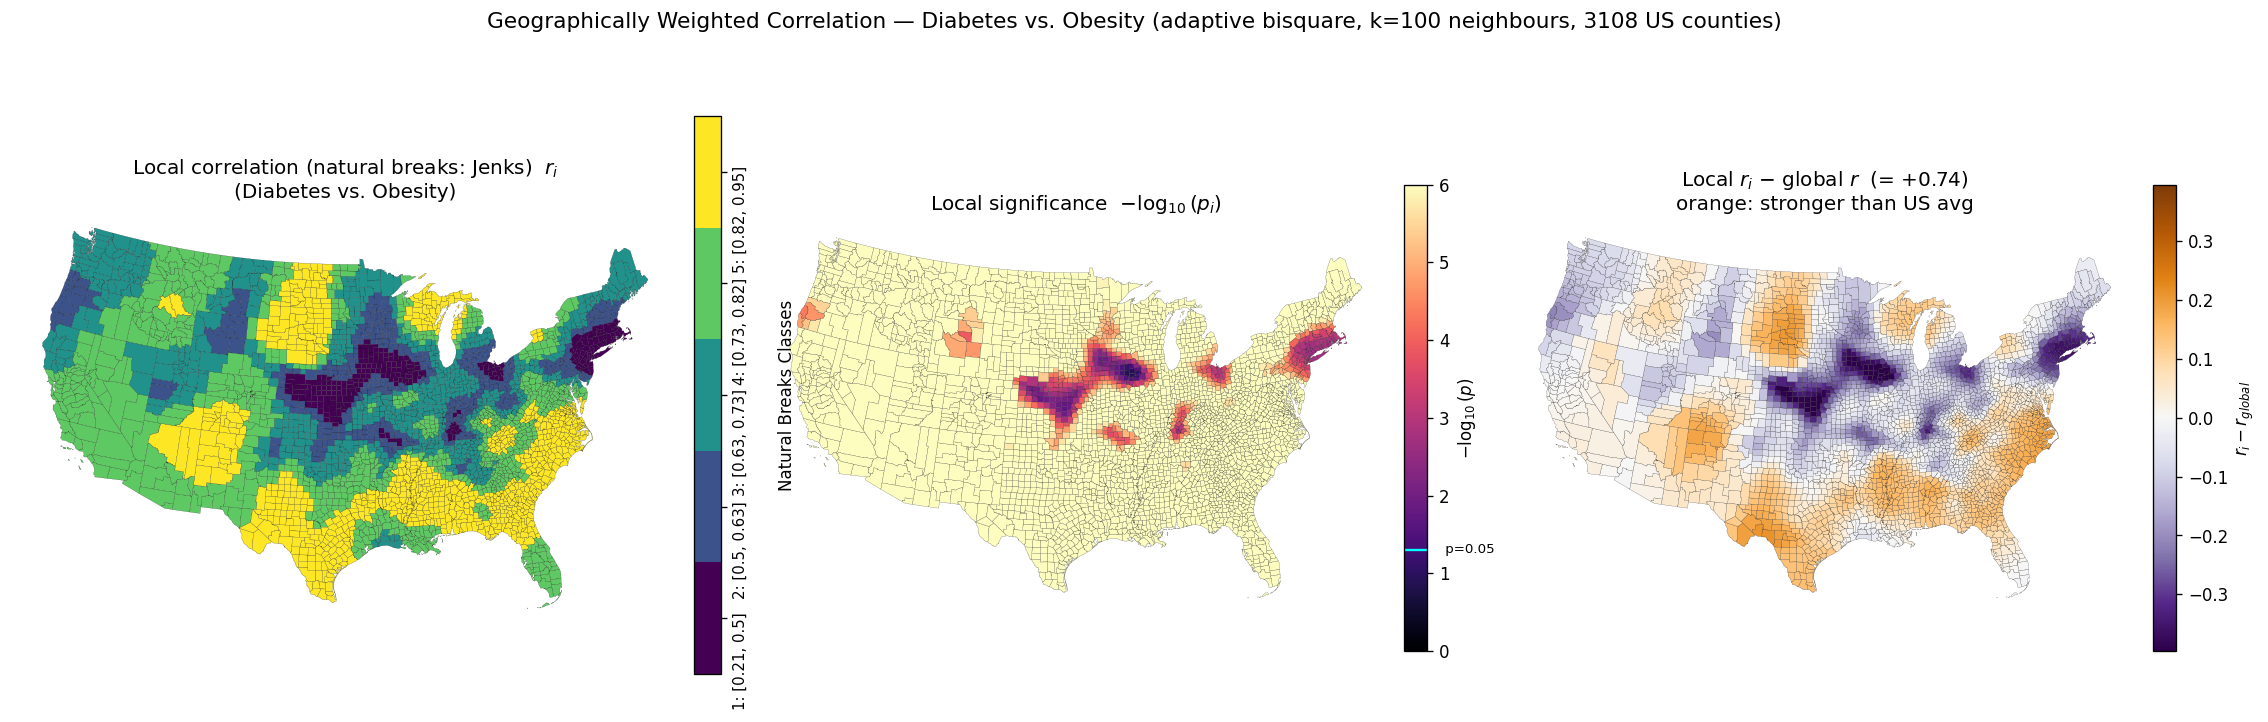

In [7]:
"""
Geographically Weighted Correlation on US county health data.
Variables: Diabetes (%) vs. Obesity (%).
Produces choropleth-style centroid maps of local r and local p-values.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib as mpl

mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

# --------------------------------------------------------------------------- #
# Data: use gdf["Diabetes"] and gdf["Obesity"] and centroids for coordinates  #
# --------------------------------------------------------------------------- #

# Extract variables from gdf
x = gdf["Obesity"].to_numpy()
y = gdf["Diabetes"].to_numpy()
coords = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])

K = 100  # adaptive bandwidth: nearest neighbours
r, p = geo_weighted_correlation(
    x, y, coords, bw=K, kernel="bisquare", adaptive=True,
    distance="euclidean", method="pearson",
    return_pvalues=True, pvalue_method="parametric",
)

sig = p < 0.05
print(f"Global Pearson r : {np.corrcoef(x, y)[0, 1]:+.3f}")
print(f"Local r          : mean {np.nanmean(r):+.3f}, "
      f"range [{np.nanmin(r):+.3f}, {np.nanmax(r):+.3f}]")
print(f"Significant (p<.05): {sig.mean()*100:.1f}% of counties "
      f"({sig.sum()} / {len(sig)})")
neg_sig = sig & (r < 0)
print(f"Significant & negative: {neg_sig.sum()} counties")

# --------------------------------------------------------------------------- #
# Maps  (polygon choropleths — color US counties polygons)
# --------------------------------------------------------------------------- #

fig, axes = plt.subplots(1, 3, figsize=(19, 6.2))

# ---- Panel A: local r -----------------------------------------------------
# Panel A: Plotting Local Correlation Map with Natural Breaks (Jenks) and Sidebar

import mapclassify

axA = axes[0]

# Compute natural breaks (Jenks) for r
nbreaks = 5
scheme = mapclassify.NaturalBreaks(r, k=nbreaks)
bin_labels = []
bin_edges = np.round(scheme.bins, 2)
prev = np.round(np.min(r), 2)
for idx, edge in enumerate(bin_edges):
    bin_labels.append(f"{idx+1}: [{prev}, {edge}]")
    prev = edge

# Assign bin numbers and labels to the dataframe
gdf_plot = gdf.copy()
gdf_plot["nbreak"] = scheme.yb
gdf_plot["nb_label"] = [bin_labels[i] for i in scheme.yb]

# Define color map for bins
cmapA = plt.get_cmap('viridis', nbreaks)
colorsA = [cmapA(i) for i in range(nbreaks)]
bin_color_map = dict(zip(range(nbreaks), colorsA))

# Plot natural breaks map
gdf_plot.plot(
    column="nbreak", 
    ax=axA, 
    cmap=cmapA, 
    linewidth=0.1,
    edgecolor='k',
    legend=False  # We'll make custom sidebar
)

axA.set_title("Local correlation (natural breaks: Jenks)  $r_i$\n(Diabetes vs. Obesity)", fontsize=12)

# Make a sidebar legend on the RIGHT side, moved even closer to the map
from matplotlib.patches import Patch

legend_patches = [Patch(facecolor=bin_color_map[b], label=lbl) for b, lbl in enumerate(bin_labels)]
# Move the side bar very close to the right of Panel A
# [left, bottom, width, height] -- adjust 'left' to minimize the gap
side_bar_ax = fig.add_axes([0.307, 0.13, 0.012, 0.75])  # further reduced left value for minimal gap

smA = plt.cm.ScalarMappable(cmap=cmapA, norm=plt.Normalize(vmin=0, vmax=nbreaks))
cbA = plt.colorbar(smA, cax=side_bar_ax, boundaries=np.arange(-0.5, nbreaks, 1), ticks=np.arange(nbreaks), orientation='vertical')
cbA.set_ticks(np.arange(nbreaks))
cbA.set_ticklabels(bin_labels, rotation=90)
cbA.ax.tick_params(labelsize=9)
cbA.set_label("Natural Breaks Classes", fontsize=10, rotation=90, labelpad=18)

# ---- Panel B: local p-value ----------------------------------------------
axB = axes[1]
logp = -np.log10(np.clip(p, 1e-12, 1.0))
vminB, vmaxB = 0, 6
gdf.plot(column=logp, ax=axB, cmap="magma", vmin=vminB, vmax=vmaxB, linewidth=0.1, edgecolor='k')
axB.set_title("Local significance  $-\\log_{10}(p_i)$", fontsize=12)
smB = plt.cm.ScalarMappable(cmap="magma", norm=plt.Normalize(vmin=vminB, vmax=vmaxB))
smB.set_array([])
cbB = fig.colorbar(smB, ax=axB, fraction=0.035, pad=0.02)
cbB.set_label("$-\\log_{10}(p)$")
# mark the p=0.05 level on the colorbar
cbB.ax.axhline(-np.log10(0.05), color="cyan", lw=1.4)
cbB.ax.text(1.6, -np.log10(0.05), " p=0.05", va="center", fontsize=8, color="black")

# ---- Panel C: local r minus global r (non-stationarity) -------------------
axC = axes[2]
r_glob = np.corrcoef(x, y)[0, 1]
dev = r - r_glob
lim = np.nanpercentile(np.abs(dev), 99)
normC = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
gdf.plot(column=dev, ax=axC, cmap="PuOr_r", norm=normC, linewidth=0.1, edgecolor='k')
axC.set_title(f"Local $r_i$ $-$ global $r$  (= {r_glob:+.2f})\n"
              "orange: stronger than US avg", fontsize=12)
smC = plt.cm.ScalarMappable(cmap="PuOr_r", norm=normC)
smC.set_array([])
cbC = fig.colorbar(smC, ax=axC, fraction=0.035, pad=0.02)
cbC.set_label("$r_i - r_{global}$")

for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle(
    "Geographically Weighted Correlation — Diabetes vs. Obesity "
    f"(adaptive bisquare, k={K} neighbours, {len(gdf)} US counties)",
    fontsize=13, y=1.02)
fig.tight_layout()
print("saved gwc_maps.png")

## 6. Geographically Weighted Regression (GWR)

**Geographically Weighted Regression (GWR)** is a way to see how the relationship between two things (like diabetes and obesity) changes from place to place.

Imagine you want to know, *"Does living in different counties change how much one thing affects another?"*

GWR works by doing a separate regression for every location, but when looking at each place, it gives more importance ("weight") to data points that are nearby, and less weight to far-away points.

In regular regression, we try to find the best line to predict $y$ using $x$ (like: $y = a + b \cdot x$).
In GWR, we let the slope and intercept ($a$ and $b$) be different in every location!

**The main idea:**
- For each place (say, county $i$), we fit a regression using all the data, but give the most weight to data closest to county $i$.
- We do this for every place, so every location gets its own "local" regression line.

**The math part (for dummies):**
- At each spot $i$, we find the line: $y = a_i + b_i x$
    - $a_i$ and $b_i$ are special to spot $i$ (they change from place to place).
- To make $a_i$ and $b_i$ focus on county $i$, we use weights: nearby counties get high weights, far ones low weights.
- These weights are often made using a **Gaussian** (bell curve). So two counties close together matter a lot; two far apart, barely matter at all.

**In symbols:**
  For each location $i$:
  $$
  y_j \approx a_i + b_i x_j
  $$
  (for all $j$, but with weights based on distance from $i$)

- The weights $w_{ij}$ get smaller as the distance between $i$ and $j$ grows:
  $$
  w_{ij} = \exp\left(-\frac{d_{ij}^2}{2h^2}\right)
  $$
  where $d_{ij}$ is the distance between $i$ and $j$, and $h$ controls "how local" you want to be.

So in the end, **GWR shows us how relationships change in different places, instead of assuming one global answer for everywhere.**

In [8]:
"""
Geographically Weighted Regression (GWR)
========================================

Local (spatially varying-coefficient) linear regression. A separate
weighted least-squares model is solved at every location, with weights
from a distance-decay kernel, yielding coefficient *surfaces* rather
than single global estimates. Companion to gwcorr.py, whose kernel /
distance / bandwidth helpers this module reuses.

Main entry points
-----------------
gwr(...)               fit GWR at a given bandwidth -> GWRResults
select_bandwidth(...)  choose bandwidth by AICc or CV (golden section)

Dependencies: numpy, scipy, and gwcorr.py on the path.
"""
from __future__ import annotations

from dataclasses import dataclass, field

import numpy as np
from scipy import stats as stdist

# from gwcorr import _distance_matrix, _kernel_weights, _bandwidth, _KERNELS


# --------------------------------------------------------------------------- #
# Results container
# --------------------------------------------------------------------------- #
@dataclass
class GWRResults:
    params: np.ndarray      # (n, k) local coefficients
    bse: np.ndarray         # (n, k) local standard errors
    tvalues: np.ndarray     # (n, k)
    pvalues: np.ndarray     # (n, k)
    predy: np.ndarray       # (n,) fitted values
    resid: np.ndarray       # (n,) residuals
    localR2: np.ndarray     # (n,) local goodness of fit
    enp: float              # effective number of parameters, tr(S)
    rss: float
    sigma2: float           # residual variance, rss / (n - enp)
    df_resid: float
    aic: float
    aicc: float
    bic: float
    R2: float
    adj_R2: float
    bw: float
    kernel: str
    adaptive: bool
    names: list = field(default_factory=list)

    def summary(self):
        n, k = self.params.shape
        bw_kind = "n neighbours" if self.adaptive else "distance"
        lines = [
            "Geographically Weighted Regression",
            "=" * 46,
            f"Observations           : {n}",
            f"Predictors (incl. int.): {k}",
            f"Kernel / bandwidth     : {self.kernel}, {self.bw:g} ({bw_kind}, "
            f"{'adaptive' if self.adaptive else 'fixed'})",
            "-" * 46,
            f"Effective params tr(S) : {self.enp:.3f}",
            f"Residual d.f.          : {self.df_resid:.3f}",
            f"RSS                    : {self.rss:.4g}",
            f"Sigma^2                : {self.sigma2:.4g}",
            f"R2 / adj-R2            : {self.R2:.3f} / {self.adj_R2:.3f}",
            f"AICc / AIC / BIC       : {self.aicc:.2f} / {self.aic:.2f} / {self.bic:.2f}",
            "-" * 46,
            "Local coefficient summary (across locations):",
            f"{'variable':<16}{'mean':>10}{'std':>10}{'min':>10}"
            f"{'median':>10}{'max':>10}{'%sig':>7}",
        ]
        for j, name in enumerate(self.names):
            b = self.params[:, j]
            sig = 100.0 * np.mean(self.pvalues[:, j] < 0.05)
            lines.append(
                f"{name:<16}{b.mean():>10.3f}{b.std():>10.3f}{b.min():>10.3f}"
                f"{np.median(b):>10.3f}{b.max():>10.3f}{sig:>6.1f}%")
        text = "\n".join(lines)
        print(text)
        return text


# --------------------------------------------------------------------------- #
# Core local fit
# --------------------------------------------------------------------------- #
def _fit_core(X, y, w, loo=False, need_cct=True):
    """Solve the local WLS at every location.

    Parameters
    ----------
    X : (n, k)   design matrix (intercept already included if wanted)
    y : (n,)     response
    w : (n, n)   weight matrix; row i holds the weights for location i
    loo : bool   leave-one-out (zero the self-weight) — used by CV
    need_cct : bool   also return diag of (X'WX)^-1 (X'W^2X) (X'WX)^-1

    Returns betas (n,k), predy (n,), tr_S (float), diagCCt (n,k) or None.
    """
    n, k = X.shape
    betas = np.empty((n, k))
    predy = np.empty(n)
    diagCCt = np.empty((n, k)) if need_cct else None
    tr_S = 0.0

    for i in range(n):
        wi = w[i]
        if loo:
            wi = wi.copy()
            wi[i] = 0.0
        Xw = X * wi[:, None]            # W X            (n, k)
        A = Xw.T @ X                    # X'W X          (k, k)
        b = Xw.T @ y                    # X'W y          (k,)
        try:
            Ainv = np.linalg.inv(A)
        except np.linalg.LinAlgError:
            Ainv = np.linalg.pinv(A)
        beta = Ainv @ b
        betas[i] = beta
        predy[i] = X[i] @ beta
        if not loo:
            # hat-matrix diagonal element  S_ii = w_ii * x_i' (X'WX)^-1 x_i
            tr_S += wi[i] * (X[i] @ Ainv @ X[i])
        if need_cct:
            Xw2 = X * (wi ** 2)[:, None]        # W^2 X
            B = Xw2.T @ X                       # X'W^2X
            diagCCt[i] = np.einsum("ij,jk,ki->i", Ainv, B, Ainv)
    return betas, predy, tr_S, diagCCt


# --------------------------------------------------------------------------- #
# Public fit
# --------------------------------------------------------------------------- #
def gwr(y, X, coords, bw, kernel="bisquare", adaptive=True,
        distance="euclidean", add_intercept=True, names=None):
    """Fit Geographically Weighted Regression.

    Parameters
    ----------
    y : (n,) array-like               response variable.
    X : (n, p) array-like             predictors (WITHOUT intercept).
    coords : (n, 2) array-like        point coordinates (projected x/y for
                                      euclidean, lon/lat for haversine).
    bw : float or int                 distance if adaptive=False, else the
                                      number of nearest neighbours k.
    kernel : {'gaussian','exponential','bisquare','tricube','boxcar'}
    adaptive : bool                   adaptive k-NN vs fixed-distance bandwidth.
    distance : {'euclidean','haversine'}
    add_intercept : bool              prepend a column of ones.
    names : list of str, optional     predictor names (excluding intercept).

    Returns
    -------
    GWRResults
    """
    y = np.asarray(y, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[:, None]
    coords = np.asarray(coords, dtype=float)
    n = y.size
    if X.shape[0] != n or coords.shape[0] != n:
        raise ValueError("y, X and coords must share the same length.")
    if kernel.lower() not in _KERNELS:
        raise ValueError(f"kernel must be one of {_KERNELS}.")

    if names is None:
        names = [f"x{j+1}" for j in range(X.shape[1])]
    else:
        names = list(names)
    if add_intercept:
        X = np.column_stack([np.ones(n), X])
        names = ["Intercept"] + names
    k = X.shape[1]

    d = _distance_matrix(coords, distance)
    band = _bandwidth(d, bw, adaptive)
    w = _kernel_weights(d, band, kernel)

    betas, predy, tr_S, diagCCt = _fit_core(X, y, w, loo=False, need_cct=True)

    resid = y - predy
    rss = float(resid @ resid)
    df_resid = n - tr_S
    sigma2 = rss / df_resid                       # v1 estimator (uses tr(S))

    bse = np.sqrt(diagCCt * sigma2)
    with np.errstate(invalid="ignore", divide="ignore"):
        tvalues = betas / bse
    pvalues = 2.0 * stdist.t.sf(np.abs(tvalues), df_resid)

    # local R^2 (geographically weighted TSS / RSS)
    Wr = w.sum(axis=1)
    ybar_w = (w @ y) / Wr
    tss_w = (w * (y[None, :] - ybar_w[:, None]) ** 2).sum(axis=1)
    rss_w = (w * (resid[None, :] ** 2)).sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        localR2 = np.where(tss_w > 0, (tss_w - rss_w) / tss_w, np.nan)

    # global diagnostics
    tss = float(((y - y.mean()) ** 2).sum())
    R2 = 1.0 - rss / tss
    adj_R2 = 1.0 - (1.0 - R2) * (n - 1) / (df_resid - 1)
    sigma2_ml = rss / n
    llf = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2_ml) + 1.0)
    aic = -2.0 * llf + 2.0 * (tr_S + 1.0)
    aicc = -2.0 * llf + 2.0 * n * (tr_S + 1.0) / (n - tr_S - 2.0)
    bic = -2.0 * llf + (tr_S + 1.0) * np.log(n)

    return GWRResults(
        params=betas, bse=bse, tvalues=tvalues, pvalues=pvalues,
        predy=predy, resid=resid, localR2=localR2,
        enp=float(tr_S), rss=rss, sigma2=sigma2, df_resid=float(df_resid),
        aic=aic, aicc=aicc, bic=bic, R2=R2, adj_R2=adj_R2,
        bw=bw, kernel=kernel, adaptive=adaptive, names=names)


# --------------------------------------------------------------------------- #
# Bandwidth selection
# --------------------------------------------------------------------------- #
def _score(y, X, d, bw, kernel, adaptive, criterion):
    """AICc or CV score for one candidate bandwidth."""
    n = y.size
    band = _bandwidth(d, bw, adaptive)
    w = _kernel_weights(d, band, kernel)
    if criterion == "cv":
        _, predy_loo, _, _ = _fit_core(X, y, w, loo=True, need_cct=False)
        return float(((y - predy_loo) ** 2).sum())
    # aicc
    _, predy, tr_S, _ = _fit_core(X, y, w, loo=False, need_cct=False)
    rss = float(((y - predy) ** 2).sum())
    if n - tr_S - 2.0 <= 0:
        return np.inf
    sigma2_ml = rss / n
    llf = -0.5 * n * (np.log(2 * np.pi) + np.log(sigma2_ml) + 1.0)
    return -2.0 * llf + 2.0 * n * (tr_S + 1.0) / (n - tr_S - 2.0)


def select_bandwidth(y, X, coords, kernel="bisquare", adaptive=True,
                     distance="euclidean", criterion="aicc",
                     add_intercept=True, bw_min=None, bw_max=None,
                     tol=1e-2, max_iter=200, verbose=False):
    """Golden-section search for the optimal bandwidth.

    criterion : {'aicc','cv'}. For adaptive search the bandwidth is the
    integer number of neighbours; for fixed search it is a distance.
    Returns (best_bw, score_history).
    """
    y = np.asarray(y, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[:, None]
    coords = np.asarray(coords, dtype=float)
    n = y.size
    if add_intercept:
        X = np.column_stack([np.ones(n), X])
    k = X.shape[1]

    d = _distance_matrix(coords, distance)

    if adaptive:
        lo = int(bw_min) if bw_min is not None else k + 2
        hi = int(bw_max) if bw_max is not None else n
    else:
        nz = d[d > 0]
        lo = float(bw_min) if bw_min is not None else np.percentile(nz, 1)
        hi = float(bw_max) if bw_max is not None else d.max()

    gr = (np.sqrt(5.0) - 1.0) / 2.0
    a, b = lo, hi
    history = {}

    def f(bw):
        if adaptive:
            bw = int(round(bw))
            bw = max(k + 2, min(bw, n))
        if bw in history:
            return history[bw]
        s = _score(y, X, d, bw, kernel, adaptive, criterion)
        history[bw] = s
        if verbose:
            print(f"  bw={bw:<10g} {criterion}={s:.4f}")
        return s

    c = b - gr * (b - a)
    dd = a + gr * (b - a)
    fc, fd = f(c), f(dd)
    for _ in range(max_iter):
        stop = (b - a) <= (1.0 if adaptive else tol)
        if stop:
            break
        if fc < fd:
            b, dd, fd = dd, c, fc
            c = b - gr * (b - a)
            fc = f(c)
        else:
            a, c, fc = c, dd, fd
            dd = a + gr * (b - a)
            fd = f(dd)
    best_bw = int(round((a + b) / 2)) if adaptive else (a + b) / 2.0
    f(best_bw)
    # pick the truly-best evaluated bandwidth (guards against edge cases)
    best_bw = min(history, key=history.get)
    return best_bw, history


# --------------------------------------------------------------------------- #
# Smoke test
# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    n = 500
    coords = rng.uniform(0, 10, size=(n, 2))
    # coefficient on x1 trends west->east from 0 to 4; intercept constant
    b1 = 0.4 * coords[:, 0]
    x1 = rng.normal(size=n)
    x2 = rng.normal(size=n)
    y = 2.0 + b1 * x1 - 1.5 * x2 + rng.normal(scale=0.5, size=n)
    X = np.column_stack([x1, x2])

    bw, hist = select_bandwidth(y, X, coords, criterion="aicc", verbose=False)
    print("Selected adaptive bandwidth (k):", bw)
    res = gwr(y, X, coords, bw=bw, names=["x1", "x2"])
    res.summary()

    # recovered x1 slope should track 0.4 * easting
    east = coords[:, 0]
    corr = np.corrcoef(res.params[:, 1], 0.4 * east)[0, 1]
    print(f"\ncorr(recovered x1 slope, true slope) = {corr:.3f}")

Selected adaptive bandwidth (k): 73
Geographically Weighted Regression
Observations           : 500
Predictors (incl. int.): 3
Kernel / bandwidth     : bisquare, 73 (n neighbours, adaptive)
----------------------------------------------
Effective params tr(S) : 54.367
Residual d.f.          : 445.633
RSS                    : 114.6
Sigma^2                : 0.2572
R2 / adj-R2            : 0.976 / 0.973
AICc / AIC / BIC       : 807.22 / 793.15 / 1026.50
----------------------------------------------
Local coefficient summary (across locations):
variable              mean       std       min    median       max   %sig
Intercept            1.995     0.074     1.813     1.989     2.239 100.0%
x1                   2.150     1.036     0.393     2.200     3.735 100.0%
x2                  -1.505     0.089    -1.721    -1.508    -1.296 100.0%

corr(recovered x1 slope, true slope) = 0.993


In [9]:
"""
GWR: diabetes prevalence ~ obesity + pct_65plus + pct_exercise + food_env_index
US counties (n=3108). Bandwidth chosen by AICc. Outputs coefficient-surface
maps, a local-R2 map, and a per-county results CSV.
"""
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

# from gwr import gwr, select_bandwidth

mpl.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})

# --------------------------------------------------------------------------- #
# Data
# --------------------------------------------------------------------------- #
resp = "Diabetes"
pred_cols = ["Obesity",
             "Population 65+",
             "pct_exercise",
             "Food env. index"]
labels = ["Obesity (%)", "Age 65+ (%)", "Exercise access (%)", "Food env. index"]
short = ["obesity", "pct_65plus", "pct_exercise", "food_env"]

y = gdf[resp].to_numpy(float)
X = gdf[pred_cols].to_numpy(float)
coords = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])
n = len(y)

# --------------------------------------------------------------------------- #
# Bandwidth selection (AICc) + fit
# --------------------------------------------------------------------------- #
t0 = time.time()
bw, hist = select_bandwidth(y, X, coords, kernel="bisquare", adaptive=True,
                            distance="euclidean", criterion="aicc")
print(f"AICc-optimal adaptive bandwidth: k = {bw}  "
      f"(searched {len(hist)} candidates, {time.time()-t0:.0f}s)")

res = gwr(y, X, coords, bw=bw, kernel="bisquare", adaptive=True,
          distance="euclidean", names=short)
res.summary()

# --------------------------------------------------------------------------- #
# Export per-county results
# --------------------------------------------------------------------------- #
out = df[["fips", "county", "state_abbr"]].copy()
for j, s in enumerate(res.names):
    out[f"beta_{s}"] = res.params[:, j]
    out[f"t_{s}"] = res.tvalues[:, j]
    out[f"p_{s}"] = res.pvalues[:, j]
out["localR2"] = res.localR2
out["predy"] = res.predy
out["resid"] = res.resid
print("wrote gwr_county_results.csv")


AICc-optimal adaptive bandwidth: k = 78  (searched 16 candidates, 7s)


Geographically Weighted Regression
Observations           : 3108
Predictors (incl. int.): 5
Kernel / bandwidth     : bisquare, 78 (n neighbours, adaptive)
----------------------------------------------
Effective params tr(S) : 486.749
Residual d.f.          : 2621.251
RSS                    : 1273
Sigma^2                : 0.4857
R2 / adj-R2            : 0.916 / 0.900
AICc / AIC / BIC       : 7203.76 / 7021.73 / 9968.58
----------------------------------------------
Local coefficient summary (across locations):
variable              mean       std       min    median       max   %sig
Intercept            4.126     5.897   -16.974     4.288    27.626  57.6%
obesity              0.269     0.127     0.026     0.251     0.787  96.2%
pct_65plus          -0.040     0.059    -0.338    -0.036     0.143  34.4%
pct_exercise        -0.002     0.007    -0.025    -0.003     0.026  14.1%
food_env            -0.355     0.295    -1.654    -0.316     0.138  60.9%
wrote gwr_county_results.csv


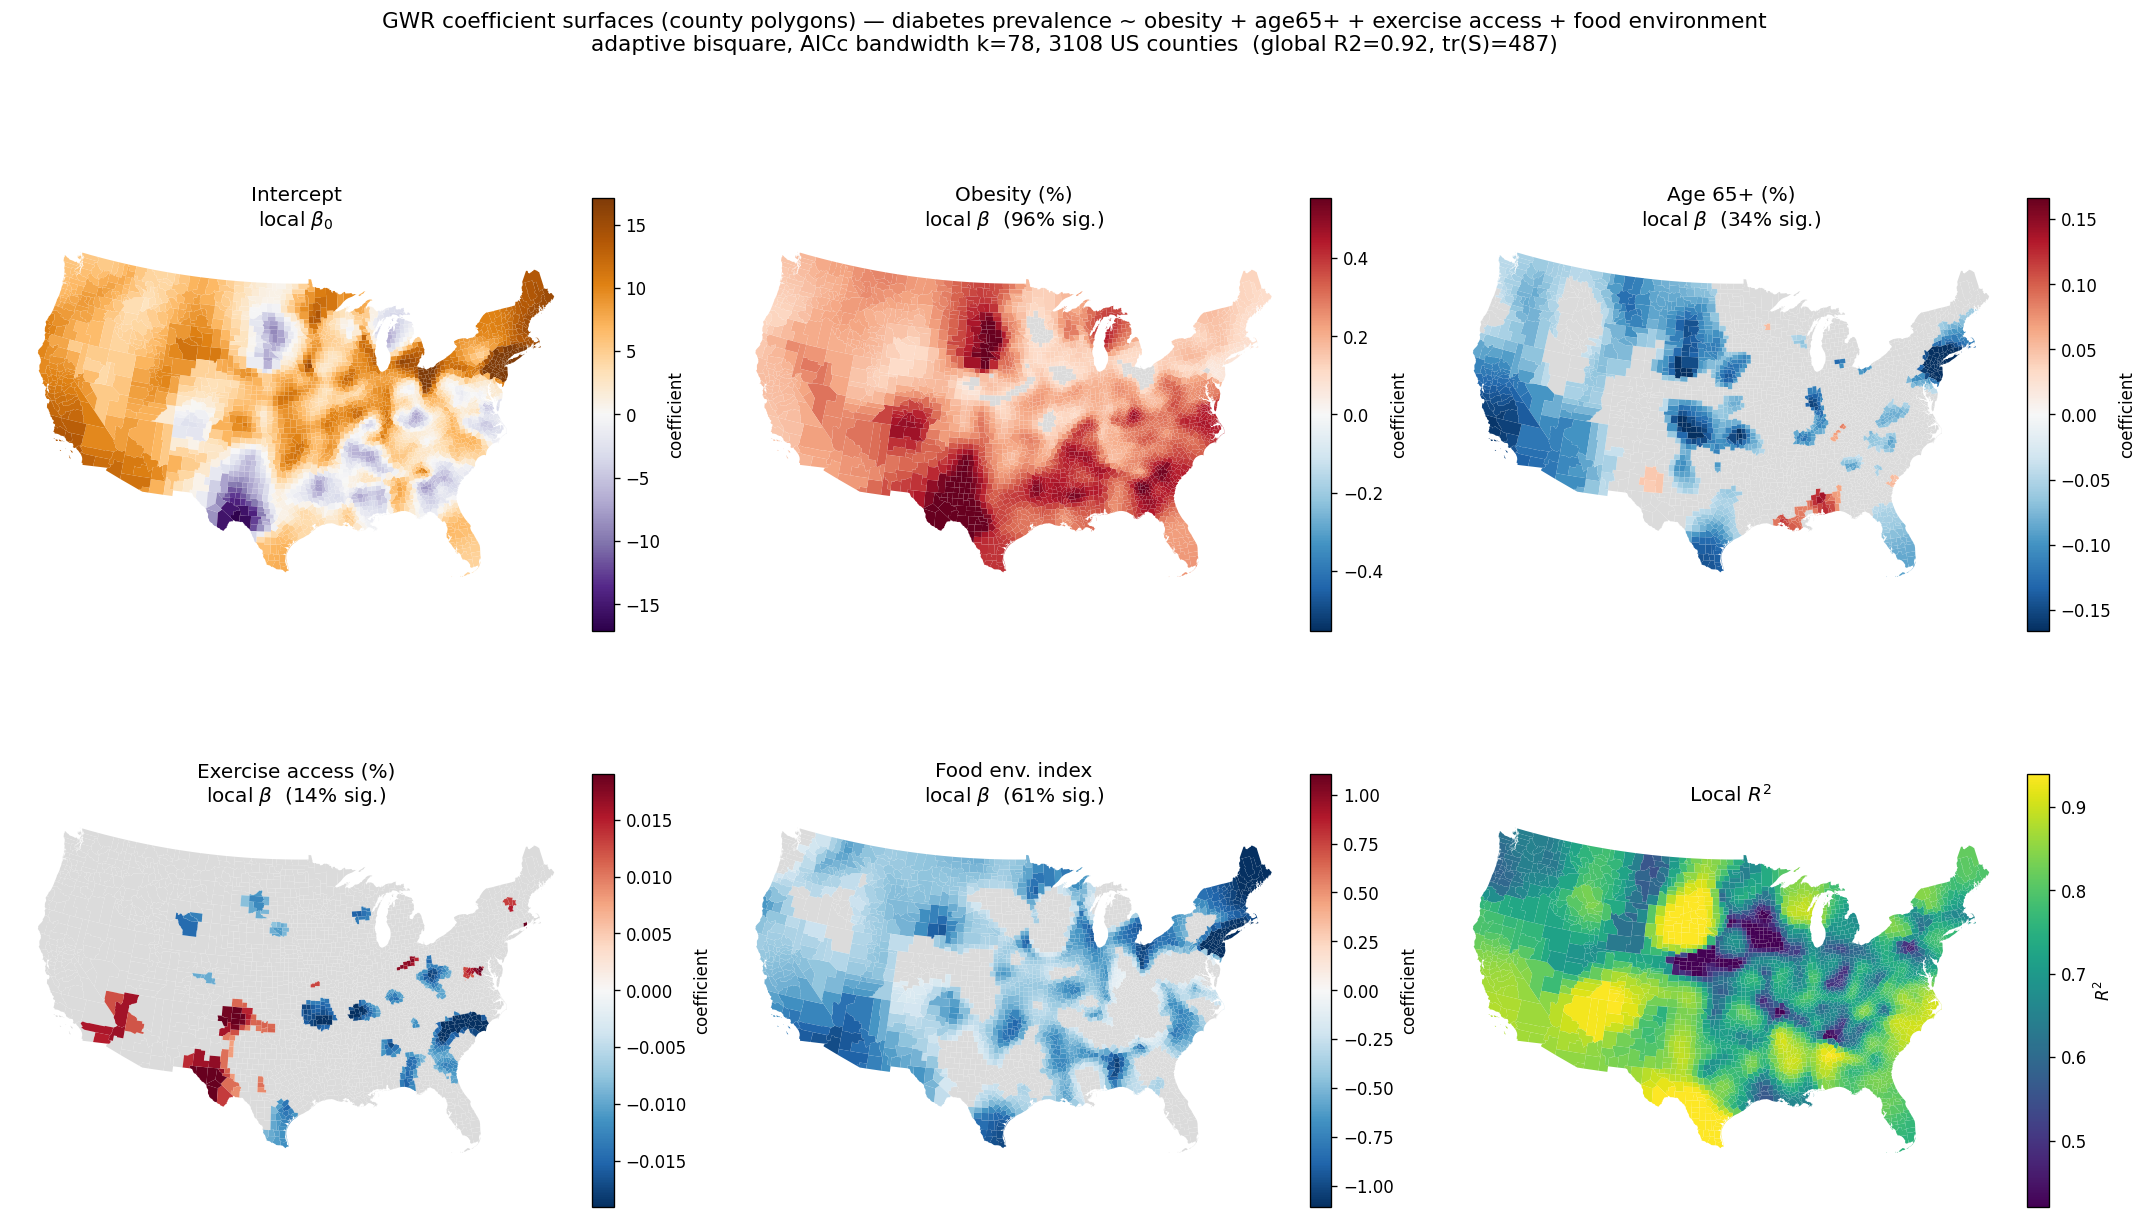

In [10]:

# --------------------------------------------------------------------------- #
# Maps: coefficient surfaces on county polygon map (grey = not significant at p<0.05) + local R2
# --------------------------------------------------------------------------- #
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
gpoly = gdf.copy()

def coef_poly_panel(ax, j, title, cmap="RdBu_r"):
    b = res.params[:, j]
    sig = res.pvalues[:, j] < 0.05
    lim = np.percentile(np.abs(b), 98)
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
    gpoly["coef"] = b
    gpoly["sig"] = sig
    # First plot non-significant polygons in gray
    gpoly[~sig].plot(ax=ax, color="0.86", linewidth=0.0)
    # Then plot significant polygons, colored by value
    gpoly_sig = gpoly[sig].copy()
    gpoly_sig = gpoly_sig.assign(
        coef_norm=gpoly_sig["coef"]
    )
    gpoly_sig.plot(ax=ax, column="coef_norm", cmap=cmap, linewidth=0.0, norm=norm)
    ax.set_title(f"{title}\nlocal $\\beta$  ({sig.mean()*100:.0f}% sig.)", fontsize=12)
    cb = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax, fraction=0.036, pad=0.02
    )
    cb.set_label("coefficient")

# intercept
b = res.params[:, 0]
lim = np.percentile(np.abs(b), 98)
gpoly["coef_intercept"] = b
gpoly.plot(
    ax=axes[0],
    column="coef_intercept",
    cmap="PuOr_r",
    linewidth=0.0,
    norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
)
axes[0].set_title("Intercept\nlocal $\\beta_0$", fontsize=12)
fig.colorbar(
    plt.cm.ScalarMappable(norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim), cmap="PuOr_r"),
    ax=axes[0], fraction=0.036, pad=0.02
).set_label("coefficient")

# four predictors
for k, (j, lab) in enumerate(zip(range(1, 5), labels), start=1):
    coef_poly_panel(axes[k], j, lab)

# local R2
r2 = res.localR2
gpoly["localR2"] = r2
gpoly.plot(
    ax=axes[5],
    column="localR2",
    cmap="viridis",
    vmin=np.percentile(r2, 2),
    vmax=np.percentile(r2, 98),
    linewidth=0.0
)
axes[5].set_title("Local $R^2$", fontsize=12)
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=mcolors.Normalize(vmin=np.percentile(r2, 2), vmax=np.percentile(r2, 98)),
        cmap="viridis"
    ),
    ax=axes[5], fraction=0.036, pad=0.02
).set_label("$R^2$")

for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle(
    "GWR coefficient surfaces (county polygons) — diabetes prevalence ~ obesity + age65+ + "
    f"exercise access + food environment\n"
    f"adaptive bisquare, AICc bandwidth k={bw}, {n} US counties  "
    f"(global R2={res.R2:.2f}, tr(S)={res.enp:.0f})",
    fontsize=13, y=1.0
)
fig.tight_layout()
plt.show()


## 6. Knowledge Check
1. The spatial lag model's rho parameter (ρ = 0.38) quantifies the extent to which diabetes prevalence in one county is associated with values in neighboring counties, beyond what is explained by covariates. Clinically, this suggests that factors affecting diabetes risk "spill over" geographically, so addressing diabetes in a county may also influence neighboring regions.
2. You should prefer the Spatial Error Model (SEM) over the Spatial Lag Model (SLM) when unmeasured or omitted variables exhibit spatial structure—i.e., when spatial autocorrelation is primarily in the error terms, not in the dependent variable itself. SEM assumes spatial dependence arises from unobserved/confounding processes.
3. When the GWR model's poverty coefficient varies widely (e.g., from 0.4 to 2.8), this could reflect either genuine regional differences in how poverty relates to diabetes, or may result from spatial artefact such as noise magnified by local estimation instability. It's important to assess whether the spatial pattern aligns with substantive knowledge and to consider model diagnostics for spurious variation.
4. The reduction in the poverty coefficient from OLS (1.42) to SLM (0.95) occurs because failing to account for spatial autocorrelation can inflate regression estimates by attributing spatially structured variation to the covariate. The SLM produces a more conservative estimate by partitioning spatial dependence from the covariate's direct effect.
5. When running GWR with two bandwidths (e.g., h=5 and h=15), the bandwidth acts as a smoothing parameter: a smaller bandwidth yields local coefficients that fluctuate more sharply (higher spatial detail, risk of overfitting), while a larger bandwidth produces smoother, more stable coefficients that approach the global (OLS) estimate.


***
**Next → NB-04: Disease Mapping & Bayesian Smoothing**
